In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
df=pd.read_csv('/content/hotel_bookings.csv')

In [ ]:
df.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


In [ ]:
df['is_repeated_guest'].value_counts()

,count
is_repeated_guest,
0,115580
1,3810


In [ ]:
df['previous_cancellations'].value_counts()

,count
previous_cancellations,
0,112906
1,6051
2,116
3,65
24,48
11,35
4,31
26,26
25,25


In [ ]:
df['previous_bookings_not_canceled'].value_counts()

,count
previous_bookings_not_canceled,
0,115770
1,1542
2,580
3,333
4,229
...,...
68,1
69,1
70,1


In [ ]:
df['booking_changes'].value_counts()

,count
booking_changes,
0,101314
1,12701
2,3805
3,927
4,376
5,118
6,63
7,31
8,17


In [ ]:
df.shape

(119390, 32)

In [ ]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

#hotel: Type of hotel (e.g., "Resort Hotel" or "City Hotel").
#is_canceled: Indicates if the booking was canceled (1) or not (0).
#lead_time: Number of days between booking date and arrival date.
#arrival_date_year: Year of arrival.
#arrival_date_month: Month of arrival (e.g., January, February).
#arrival_date_week_number: Week number of the arrival date.
#arrival_date_day_of_month: Day of the month for the arrival date.
#stays_in_weekend_nights: Number of weekend nights (Saturday/Sunday) included in the stay.
#stays_in_week_nights: Number of weeknights (Monday to Friday) included in the stay.
#adults: Number of adults in the booking.
#children: Number of children in the booking.
#babies: Number of babies in the booking.
#meal: Meal type included in the booking (e.g., BB for bed and breakfast).
#country: Country of origin of the guests.
#market_segment: Market segment designation (e.g., Online TA, Corporate).
#distribution_channel: Distribution channel used to make the booking (e.g., Direct, TA/TO).
#is_repeated_guest: Indicates if the guest is a returning customer (1) or not (0).
#previous_cancellations: Number of previous bookings canceled by the customer.
#previous_bookings_not_canceled: Number of previous bookings not canceled by the customer.
#reserved_room_type: Code of the room type reserved.
#assigned_room_type: Code of the room type assigned at check-in.
#booking_changes: Number of changes made to the booking.
#deposit_type: Type of deposit made (e.g., No Deposit, Refundable).
#agent: ID of the travel agency used for booking.
#company: ID of the company making the booking (if applicable).
#days_in_waiting_list: Number of days the booking was on a waiting list.
#customer_type: Type of customer (e.g., Contract, Group, Transient).
#adr: Average Daily Rate, which is the revenue generated per occupied room.
#required_car_parking_spaces: Number of car parking spaces required by the customer.
#total_of_special_requests: Number of special requests made by the customer.
#reservation_status: Status of the reservation (e.g., Canceled, Checked-Out).
#reservation_status_date: Date when the reservation status was updated.


In [ ]:
df.meal.unique()

array(['BB', 'FB', 'HB', 'SC', 'Undefined'], dtype=object)

In [ ]:
df.country.unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'E

In [ ]:
df.market_segment.unique()

array(['Direct', 'Corporate', 'Online TA', 'Offline TA/TO',
       'Complementary', 'Groups', 'Undefined', 'Aviation'], dtype=object)

In [ ]:
df.distribution_channel.unique()

array(['Direct', 'Corporate', 'TA/TO', 'Undefined', 'GDS'], dtype=object)

In [ ]:
df.reserved_room_type.unique()

array(['C', 'A', 'D', 'E', 'G', 'F', 'H', 'L', 'P', 'B'], dtype=object)

In [ ]:
df.assigned_room_type.unique()

array(['C', 'A', 'D', 'E', 'G', 'F', 'I', 'B', 'H', 'P', 'L', 'K'],
      dtype=object)

In [ ]:
df.deposit_type.unique()

array(['No Deposit', 'Refundable', 'Non Refund'], dtype=object)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [ ]:
df.describe()

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,119386.000000,119390.000000,119390.000000,119390.000000,119390.000000,119390.000000,103050.000000,6797.000000,119390.000000,119390.000000,119390.000000,119390.000000
mean,0.370416,104.011416,2016.156554,27.165173,15.798241,0.927599,2.500302,1.856403,0.103890,0.007949,0.031912,0.087118,0.137097,0.221124,86.693382,189.266735,2.321149,101.831122,0.062518,0.571363
std,0.482918,106.863097,0.707476,13.605138,8.780829,0.998613,1.908286,0.579261,0.398561,0.097436,0.175767,0.844336,1.497437,0.652306,110.774548,131.655015,17.594721,50.535790,0.245291,0.792798
min,0.000000,0.000000,2015.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,6.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,18.000000,2016.000000,16.000000,8.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,62.000000,0.000000,69.290000,0.000000,0.000000
50%,0.000000,69.000000,2016.000000,28.000000,16.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,14.000000,179.000000,0.000000,94.575000,0.000000,0.000000
75%,1.000000,160.000000,2017.000000,38.000000,23.000000,2.000000,3.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,229.000000,270.000000,0.000000,126.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,31.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,535.000000,543.000000,391.000000,5400.000000,8.000000,5.000000


In [ ]:
df.dtypes

,0
hotel,object
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,object
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [ ]:
categorical_list=['hotel','customer_type','reservation_status','arrival_date_month','country','market_segment','distribution_channel','reserved_room_type','assigned_room_type','deposit_type','meal']
for column in categorical_list:
  df[column]=df[column].astype('category')

In [ ]:
df['reservation_status_date']=pd.to_datetime(df['reservation_status_date'])

In [ ]:
df.dtypes

,0
hotel,category
is_canceled,int64
lead_time,int64
arrival_date_year,int64
arrival_date_month,category
arrival_date_week_number,int64
arrival_date_day_of_month,int64
stays_in_weekend_nights,int64
stays_in_week_nights,int64
adults,int64


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df=df.dropna(subset=['agent', 'company'])

In [ ]:
df.children.unique()

array([0., 1., 2.])

In [ ]:
df['children']=df['children'].fillna(0)

In [ ]:
mode_value = df['country'].mode()[0]
df['country'].fillna(mode_value, inplace=True)

In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
df.days_in_waiting_list.unique()

array([0])

In [ ]:
df.customer_type.unique()

['Transient', 'Transient-Party', 'Group', 'Contract']
Categories (4, object): ['Contract', 'Group', 'Transient', 'Transient-Party']

In [ ]:
mode_value = df['customer_type'].mode()[0]
df['customer_type'].fillna(mode_value, inplace=True)

In [ ]:
df['adr'].unique()

array([ 82.  ,  52.2 ,  48.  ,  40.  ,  42.55,  36.  ,  43.2 ,  42.  ,
        36.75,  40.5 ,  58.2 ,  70.  , 101.  , 117.5 ,  25.  ,  53.  ,
        35.1 ,   0.  ,  49.67,  86.4 ,  37.43,  49.11,  49.5 ,  49.2 ,
        53.45,  37.6 ,  57.  ,  34.2 ,  38.  ,  81.  ,  30.  ,  37.  ,
        67.5 ,  76.  , 189.  , 246.  , 224.  , 212.6 ,  43.  ,  44.  ,
        40.4 ,  66.5 ,  87.13,  96.4 , 163.4 , 135.  , 105.  , 114.  ,
       115.  ,  85.  ,  92.  , 124.  , 108.  , 123.5 ,  72.  ,  94.  ,
       110.  ,  95.  , 101.15, 194.  , 159.  , 100.75, 195.  ,  89.89,
        80.  ,  93.36, 104.5 ,  98.  , 150.  , 120.6 ])

In [ ]:
mean_value = df['adr'].mean()
df['adr'].fillna(mean_value, inplace=True)

In [ ]:
df['required_car_parking_spaces'].unique()

array([1, 0])

In [ ]:

df['required_car_parking_spaces'].fillna(0, inplace=True)


In [ ]:
df['total_of_special_requests'].unique()

array([1, 0, 2, 3])

In [ ]:
df['total_of_special_requests'].fillna(0, inplace=True)


In [ ]:
df['reservation_status'].unique()

['Check-Out', 'Canceled', 'No-Show']
Categories (3, object): ['Canceled', 'Check-Out', 'No-Show']

In [ ]:
mode_value = df['reservation_status'].mode()[0]
df['reservation_status'].fillna(mode_value, inplace=True)

In [ ]:
df['reservation_status_date'].unique()

<DatetimeArray>
['2015-10-13 00:00:00', '2015-11-17 00:00:00', '2015-11-06 00:00:00',
 '2015-11-15 00:00:00', '2015-11-16 00:00:00', '2015-11-04 00:00:00',
 '2015-10-23 00:00:00', '2015-11-10 00:00:00', '2015-11-09 00:00:00',
 '2015-11-11 00:00:00', '2015-11-14 00:00:00', '2015-11-12 00:00:00',
 '2016-05-11 00:00:00', '2016-10-17 00:00:00', '2017-05-15 00:00:00',
 '2015-12-11 00:00:00', '2017-02-01 00:00:00', '2015-10-30 00:00:00',
 '2015-11-25 00:00:00', '2016-05-17 00:00:00', '2015-11-07 00:00:00',
 '2015-11-08 00:00:00', '2017-03-02 00:00:00', '2015-12-02 00:00:00',
 '2016-01-08 00:00:00', '2016-05-03 00:00:00', '2016-02-18 00:00:00',
 '2016-03-17 00:00:00', '2016-04-04 00:00:00', '2016-05-16 00:00:00',
 '2016-07-05 00:00:00', '2016-07-10 00:00:00', '2016-09-03 00:00:00',
 '2016-09-12 00:00:00', '2016-11-29 00:00:00', '2016-12-22 00:00:00',
 '2016-12-24 00:00:00', '2017-01-06 00:00:00', '2017-01-25 00:00:00',
 '2017-03-07 00:00:00', '2017-03-12 00:00:00', '2017-06-13 00:00:00',
 '20

In [ ]:
df['reservation_status_date'] = pd.to_datetime(df['reservation_status_date'])
df['reservation_status_date'] = df['reservation_status_date'].interpolate()


In [ ]:
df['days_in_waiting_list'].unique()

array([0])

In [ ]:
df['days_in_waiting_list'].fillna(0, inplace=True)


In [ ]:
df.isnull().sum()

,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


#numerical_data:is_canceled,lead_time,arrival_date_year,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,agent,company,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests

#categorical_data:hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status

#date_time_data:reservation_status_date


**UNIVARIENT ANALYSIS**
#numerical_data

<Axes: xlabel='is_canceled', ylabel='Count'>

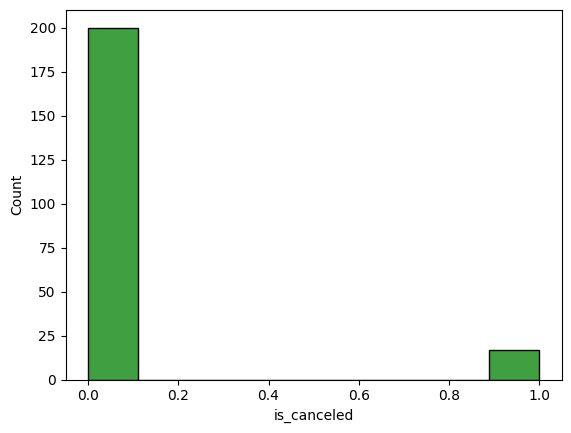

In [ ]:
sns.histplot(df['is_canceled'],color='green')

**conclusion:**from this graph we conclude that most of the bookings are not canceled only 1% are canceled.

<Axes: xlabel='lead_time', ylabel='Count'>

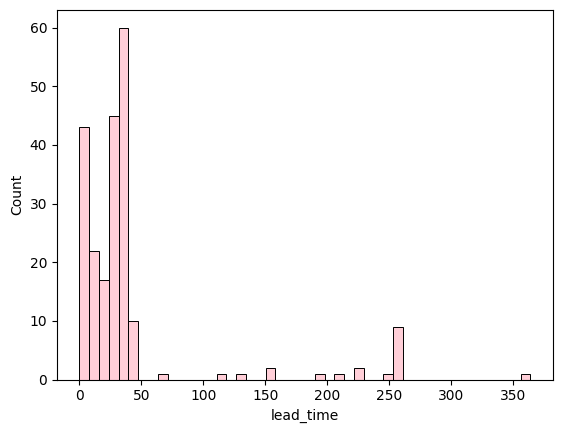

In [ ]:
sns.histplot(df['lead_time'],color='pink')

**conclusion:**from this graph we conclude that most of the people arrived   

<Axes: xlabel='arrival_date_year', ylabel='Count'>

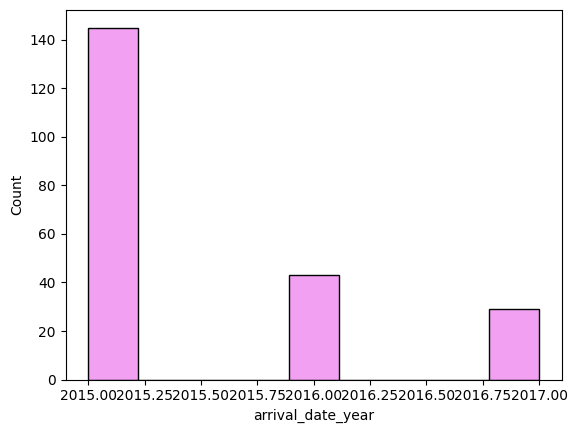

In [ ]:
sns.histplot(df['arrival_date_year'],color='violet')

<Axes: xlabel='arrival_date_week_number', ylabel='Count'>

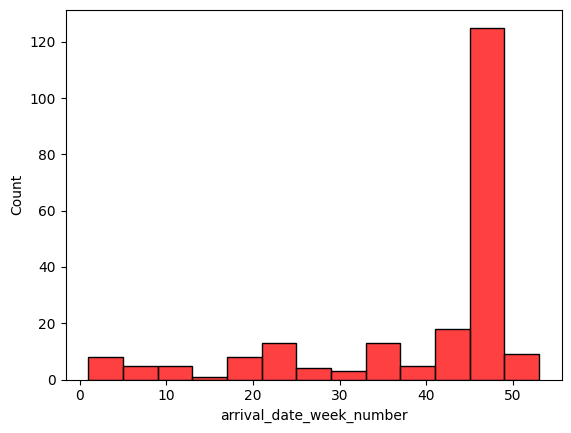

In [ ]:
sns.histplot(df['arrival_date_week_number'],color='red')

<Axes: xlabel='arrival_date_day_of_month', ylabel='Count'>

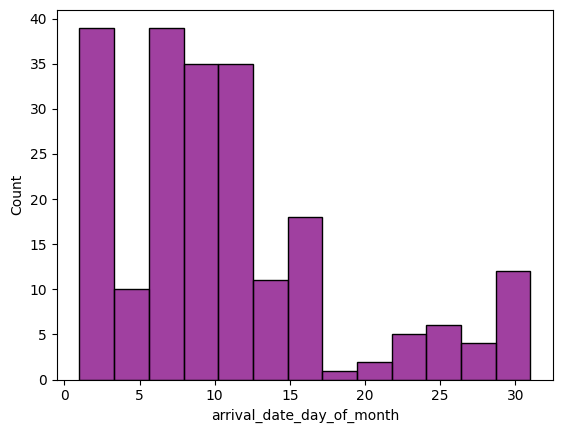

In [ ]:
sns.histplot(df['arrival_date_day_of_month'],color='purple')

<Axes: xlabel='stays_in_weekend_nights', ylabel='Count'>

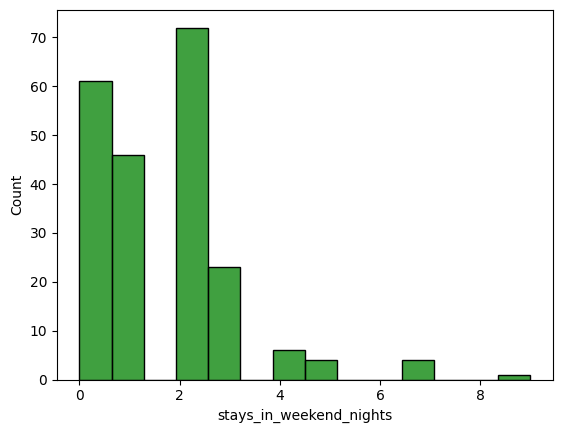

In [ ]:
sns.histplot(df['stays_in_weekend_nights'],color='green')

<Axes: xlabel='stays_in_week_nights', ylabel='Count'>

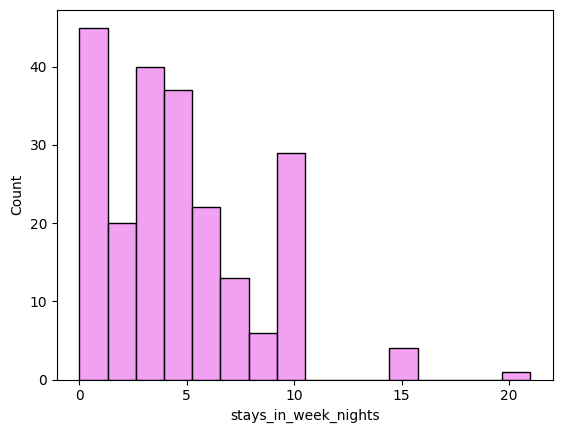

In [ ]:
sns.histplot(df['stays_in_week_nights'],color='violet')

<Axes: xlabel='adults', ylabel='Count'>

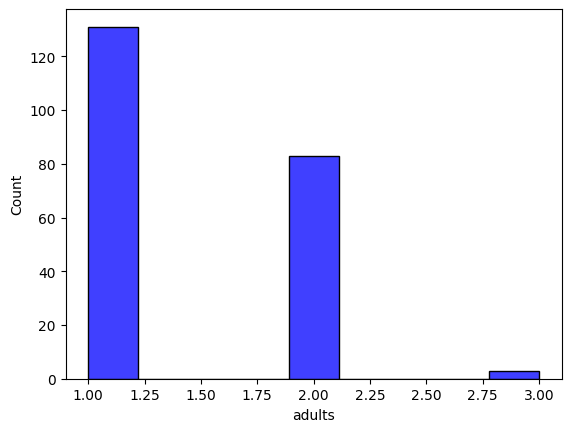

In [ ]:
sns.histplot(df['adults'],color='blue')

<Axes: xlabel='children', ylabel='Count'>

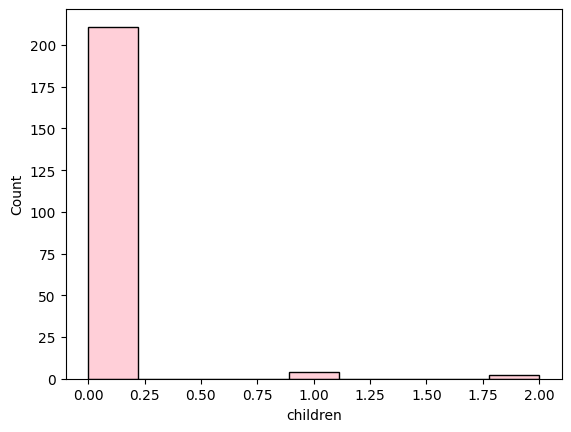

In [ ]:
sns.histplot(df['children'],color='pink')

<Axes: xlabel='is_repeated_guest', ylabel='Count'>

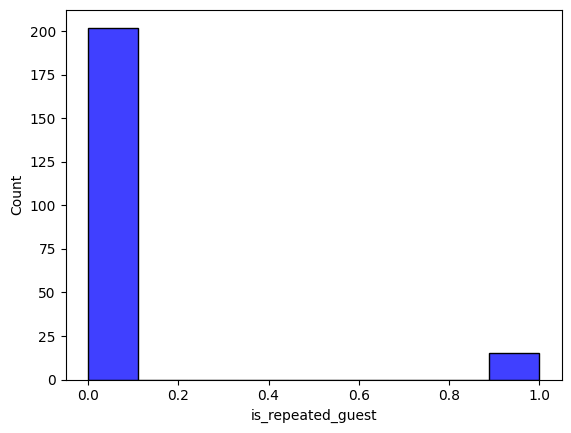

In [ ]:
sns.histplot(df['is_repeated_guest'],color='blue')

<Axes: xlabel='previous_cancellations', ylabel='Count'>

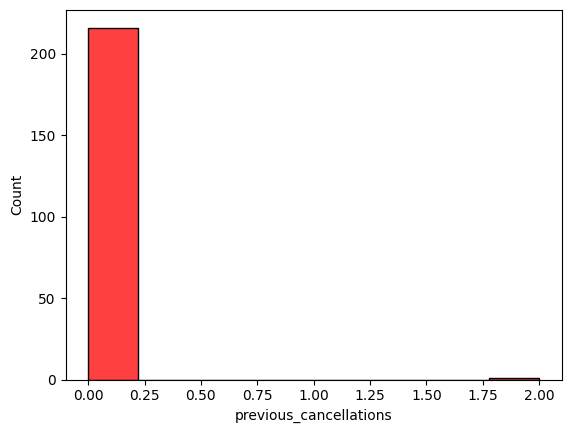

In [ ]:
sns.histplot(df['previous_cancellations'],color='red')

<Axes: xlabel='previous_bookings_not_canceled', ylabel='Count'>

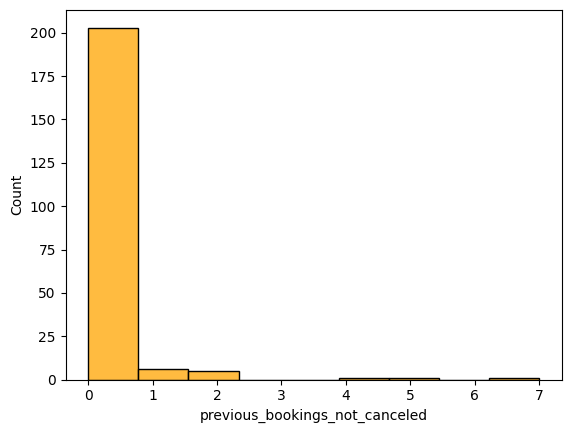

In [ ]:
sns.histplot(df['previous_bookings_not_canceled'],color='orange')

<Axes: xlabel='booking_changes', ylabel='Count'>

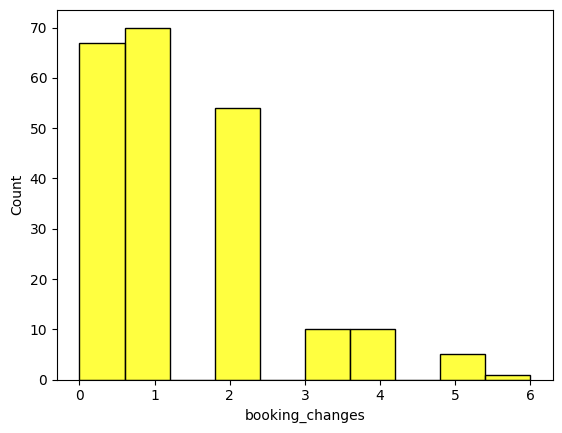

In [ ]:
sns.histplot(df['booking_changes'],color='yellow')

<Axes: xlabel='agent', ylabel='Count'>

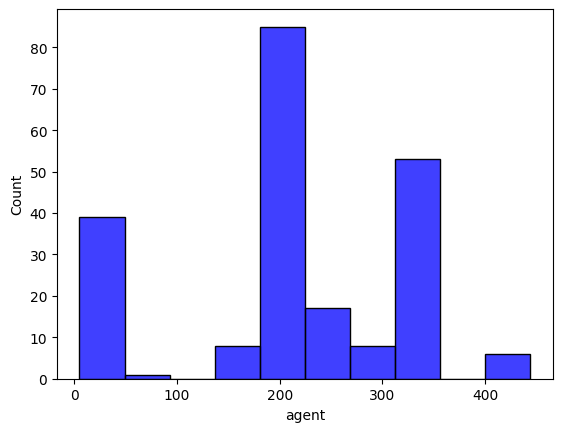

In [ ]:
sns.histplot(df['agent'],color='blue')

<Axes: xlabel='company', ylabel='Count'>

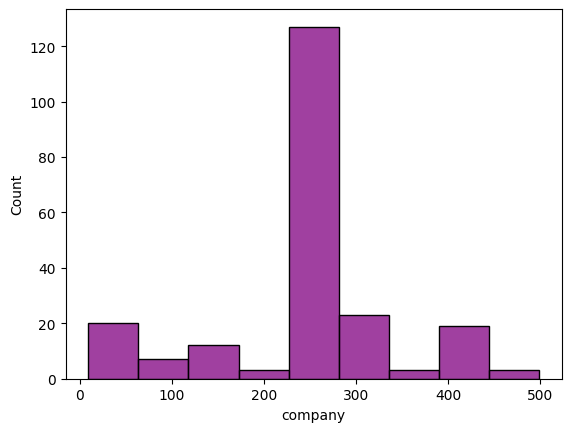

In [ ]:
sns.histplot(df['company'],color='purple')

<Axes: xlabel='adr', ylabel='Count'>

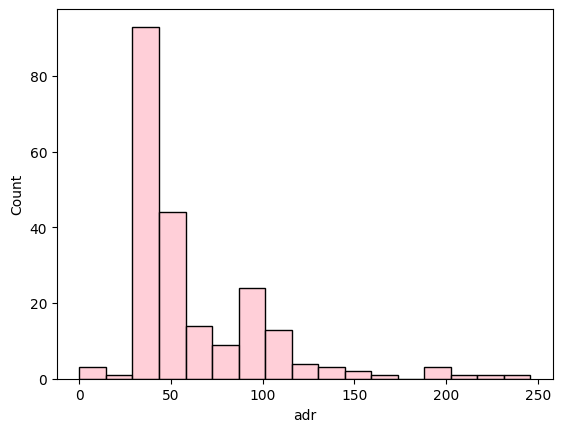

In [ ]:
sns.histplot(df['adr'],color='pink')

<Axes: xlabel='required_car_parking_spaces', ylabel='Count'>

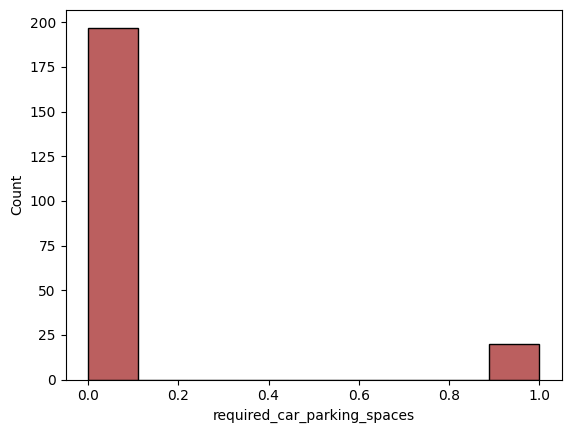

In [ ]:
sns.histplot(df['required_car_parking_spaces'],color='brown')

<Axes: xlabel='total_of_special_requests', ylabel='Count'>

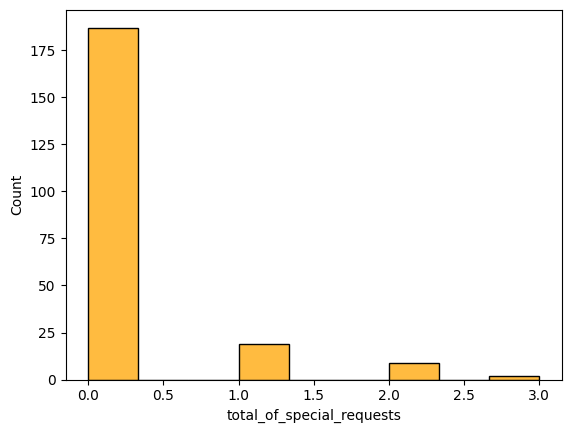

In [ ]:
sns.histplot(df['total_of_special_requests'],color='orange')

**categorical_data**:hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,assigned_room_type,deposit_type,customer_type,reservation_status

<Axes: xlabel='hotel', ylabel='count'>

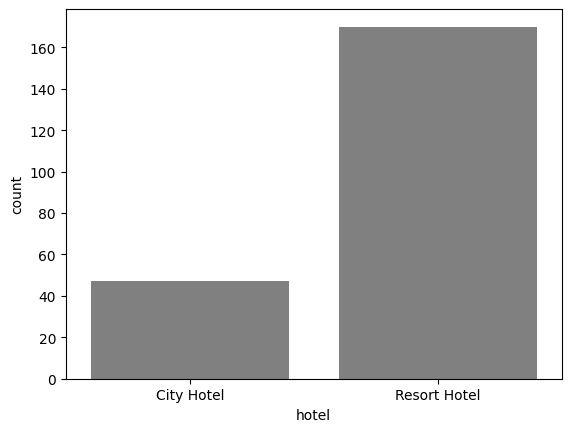

In [ ]:
sns.countplot(x=df['hotel'],color='grey')

<Axes: xlabel='count', ylabel='arrival_date_month'>

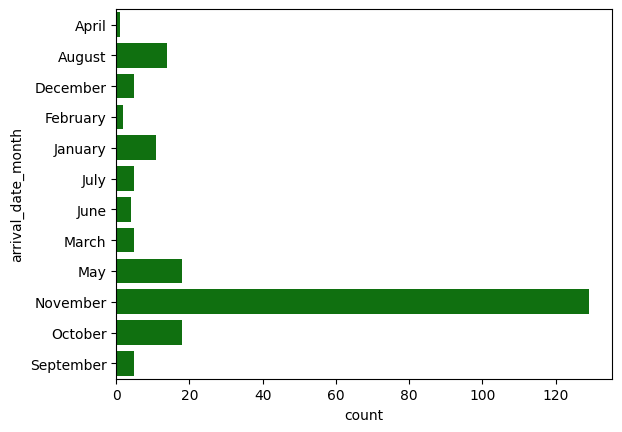

In [ ]:
sns.countplot(df['arrival_date_month'],color='green')

<Axes: xlabel='meal', ylabel='count'>

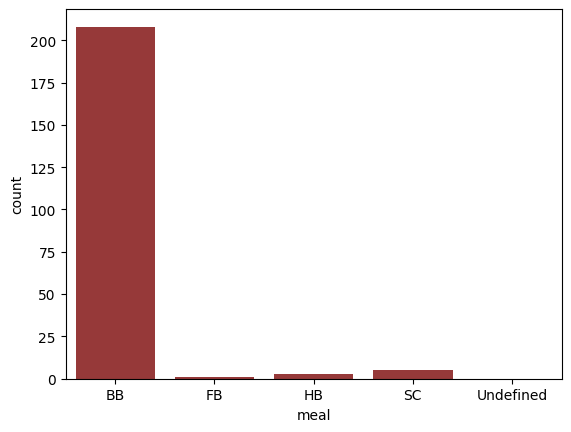

In [ ]:
sns.countplot(x=df['meal'],color='brown')

<Axes: xlabel='market_segment', ylabel='count'>

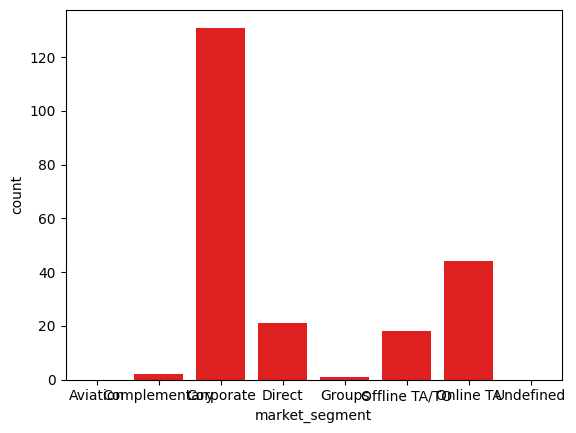

In [ ]:
sns.countplot(x=df['market_segment'],color='red')

<Axes: xlabel='distribution_channel', ylabel='count'>

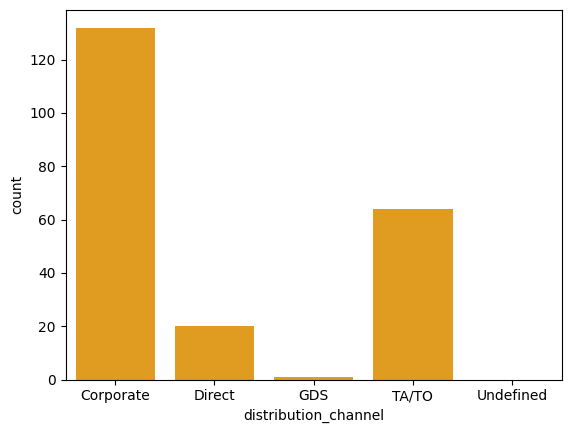

In [ ]:
sns.countplot(x=df['distribution_channel'],color='orange')

<Axes: xlabel='reserved_room_type', ylabel='count'>

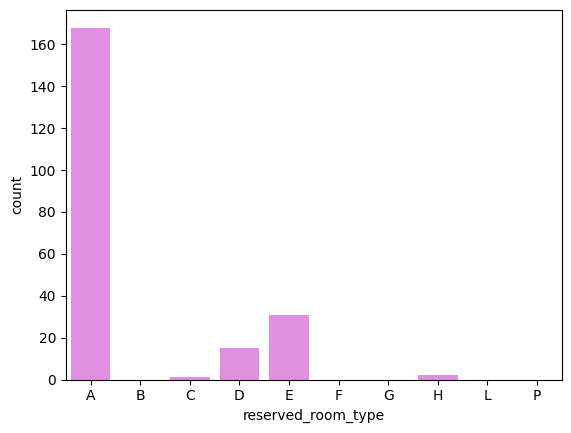

In [ ]:
sns.countplot(x=df['reserved_room_type'],color='violet')

<Axes: xlabel='assigned_room_type', ylabel='count'>

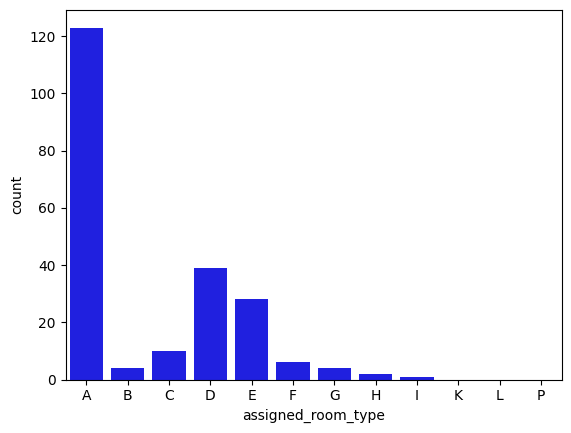

In [ ]:
sns.countplot(x=df['assigned_room_type'],color='blue')

<Axes: xlabel='deposit_type', ylabel='count'>

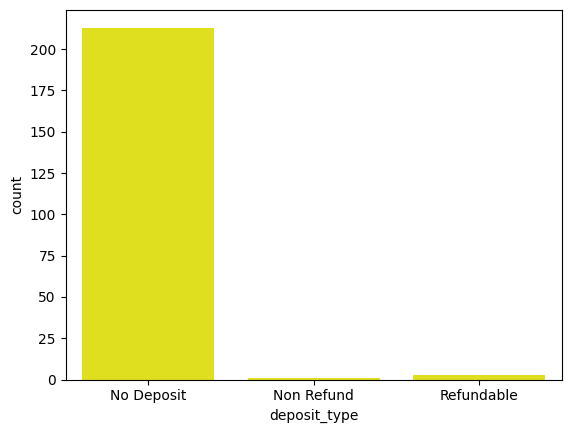

In [ ]:
sns.countplot(x=df['deposit_type'],color='yellow')

<Axes: xlabel='customer_type', ylabel='count'>

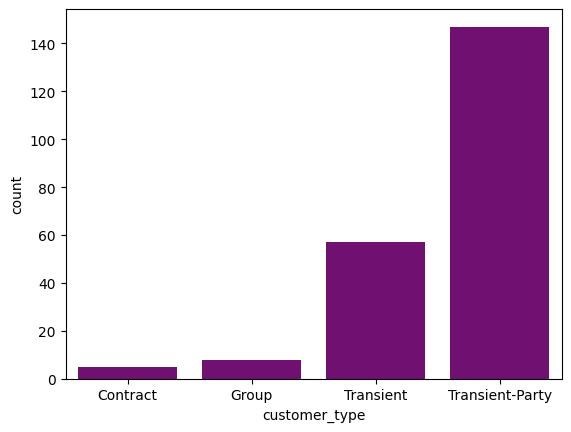

In [ ]:
sns.countplot(x=df['customer_type'],color='purple')

<Axes: xlabel='reservation_status', ylabel='count'>

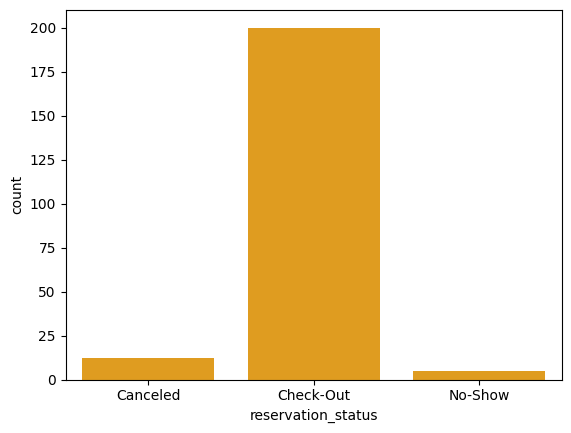

In [ ]:
sns.countplot(x=df['reservation_status'],color='orange')

**BIVARIENT ANALYSIS**
#numerical vs numerical

<Axes: xlabel='reservation_status_date', ylabel='arrival_date_week_number'>

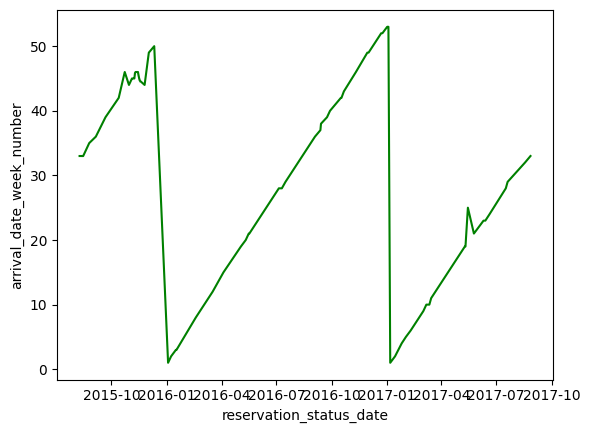

In [ ]:
sns.lineplot(x='reservation_status_date',y='arrival_date_week_number',data=df,color='green')

<Axes: xlabel='reservation_status_date', ylabel='lead_time'>

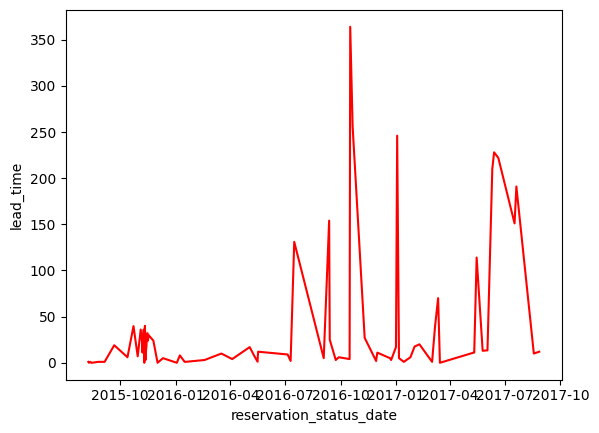

In [ ]:
sns.lineplot(x='reservation_status_date',y='lead_time',data=df,color='red')

<Axes: xlabel='reservation_status_date', ylabel='stays_in_weekend_nights'>

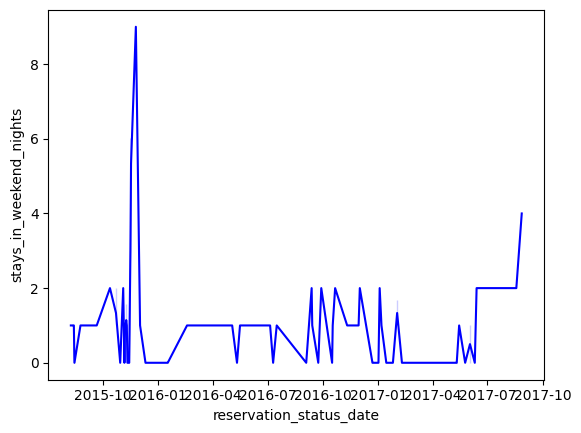

In [ ]:
sns.lineplot(x='reservation_status_date',y='stays_in_weekend_nights',data=df,color='blue')

<Axes: xlabel='reservation_status_date', ylabel='stays_in_week_nights'>

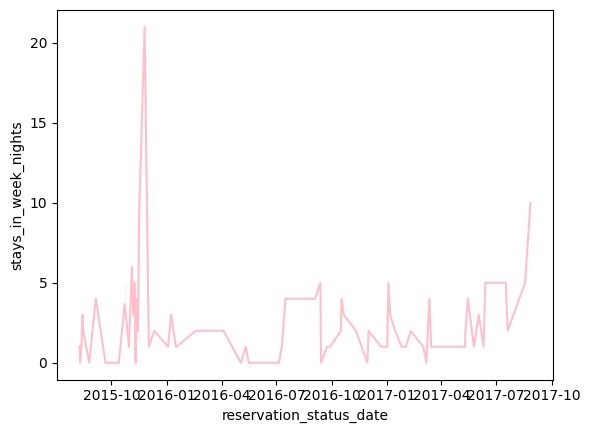

In [ ]:
sns.lineplot(x='reservation_status_date',y='stays_in_week_nights',data=df,color='pink')

<Axes: xlabel='arrival_date_year', ylabel='lead_time'>

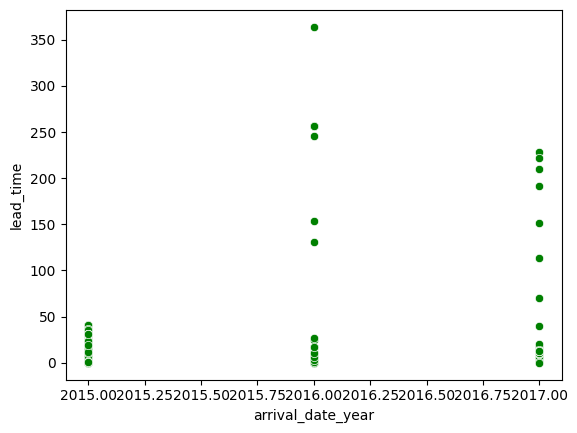

In [ ]:
sns.scatterplot(x='arrival_date_year',y='lead_time',data=df,color='green')

<Axes: xlabel='arrival_date_year', ylabel='stays_in_weekend_nights'>

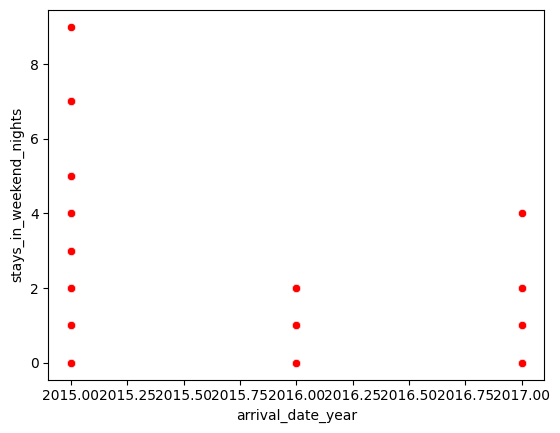

In [ ]:
sns.scatterplot(x='arrival_date_year',y='stays_in_weekend_nights',data=df,color='red')

<Axes: xlabel='arrival_date_year', ylabel='stays_in_week_nights'>

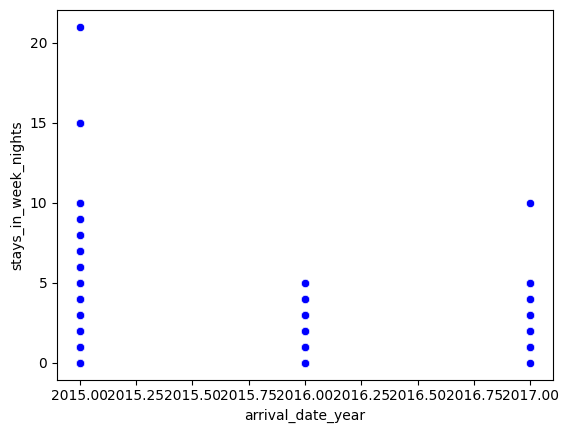

In [ ]:
sns.scatterplot(x='arrival_date_year',y='stays_in_week_nights',data=df,color='blue')

<Axes: xlabel='arrival_date_year', ylabel='adults'>

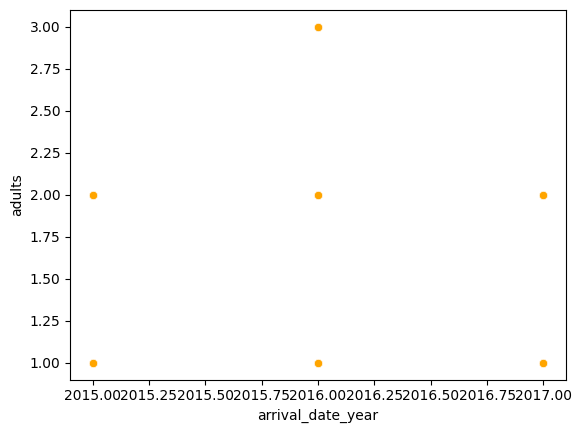

In [ ]:
sns.scatterplot(x='arrival_date_year',y='adults',data=df,color='orange')

<Axes: xlabel='arrival_date_year', ylabel='children'>

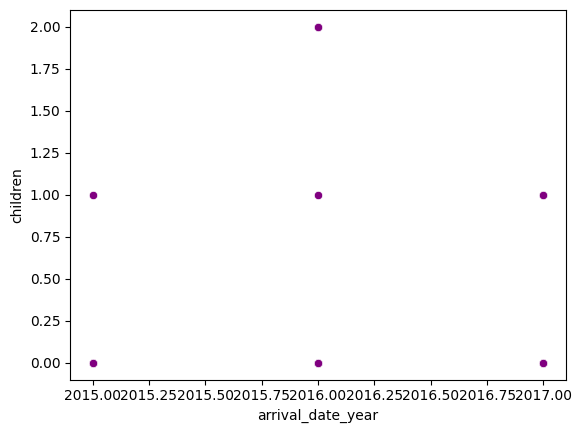

In [ ]:
sns.scatterplot(x='arrival_date_year',y='children',data=df,color='purple')

<Axes: xlabel='arrival_date_year', ylabel='babies'>

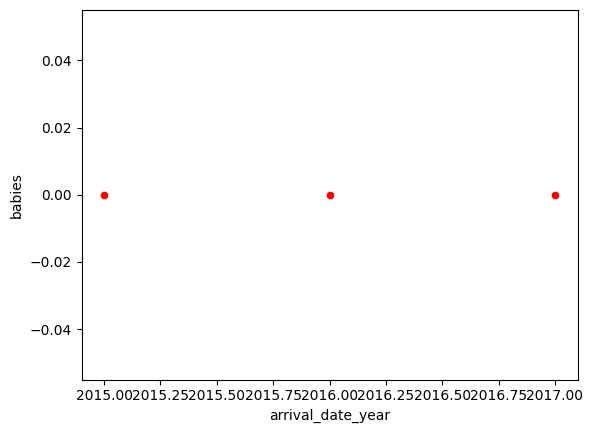

In [ ]:
sns.scatterplot(x='arrival_date_year',y='babies',data=df,color='red')

<Axes: xlabel='arrival_date_year', ylabel='adr'>

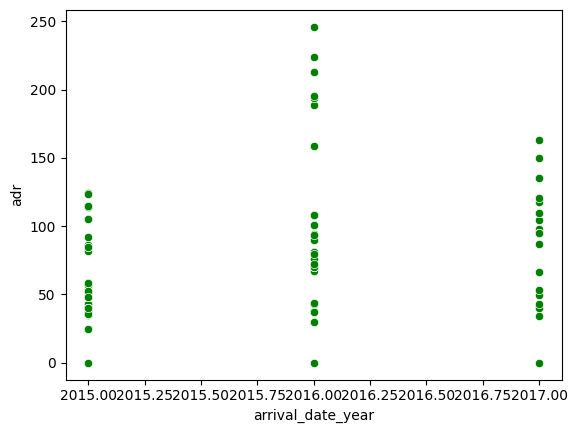

In [ ]:
sns.scatterplot(x='arrival_date_year',y='adr',data=df,color='green')

<Axes: xlabel='agent', ylabel='company'>

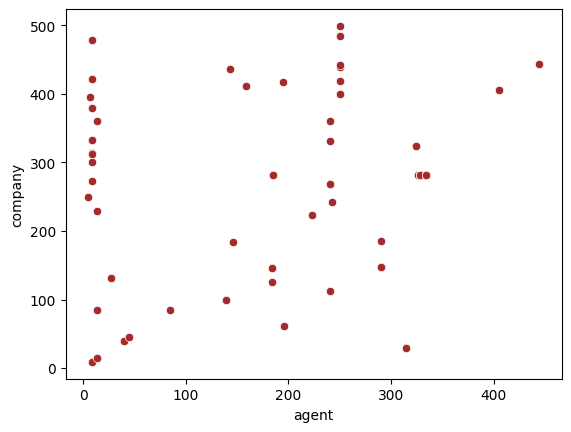

In [ ]:
sns.scatterplot(x='agent',y='company',data=df,color='brown')

**categorical vs numerical**

<Axes: xlabel='hotel', ylabel='is_repeated_guest'>

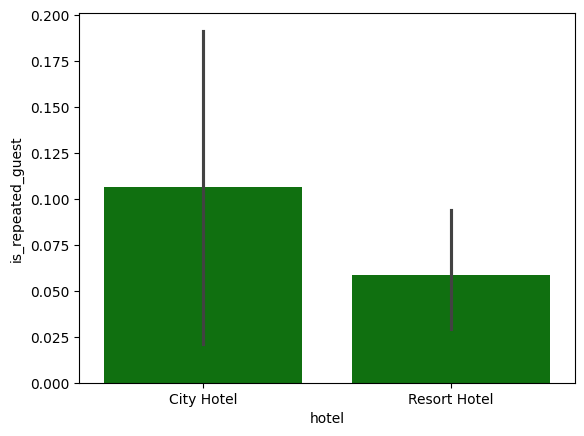

In [ ]:
sns.barplot(x='hotel',y='is_repeated_guest',data=df,color='green')

<Axes: xlabel='hotel', ylabel='lead_time'>

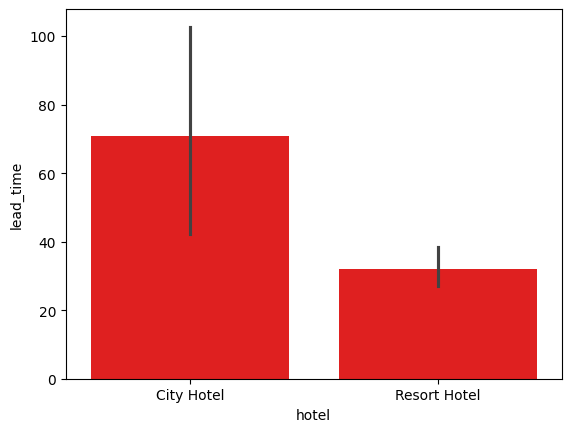

In [ ]:
sns.barplot(x='hotel',y='lead_time',data=df,color='red')

<Axes: xlabel='hotel', ylabel='stays_in_weekend_nights'>

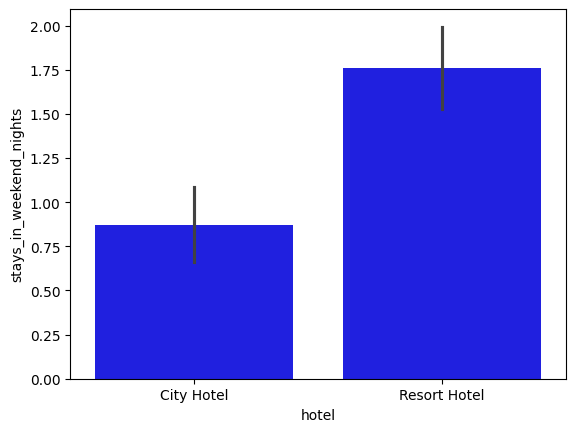

In [ ]:
sns.barplot(x='hotel',y='stays_in_weekend_nights',data=df,color='blue')

<Axes: xlabel='hotel', ylabel='adults'>

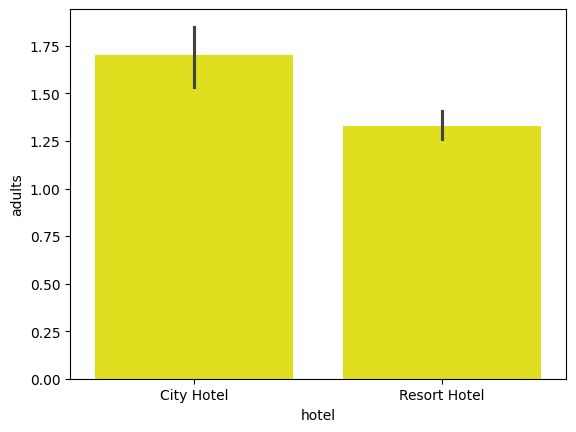

In [ ]:
sns.barplot(x='hotel',y='adults',data=df,color='yellow')

<Axes: xlabel='hotel', ylabel='children'>

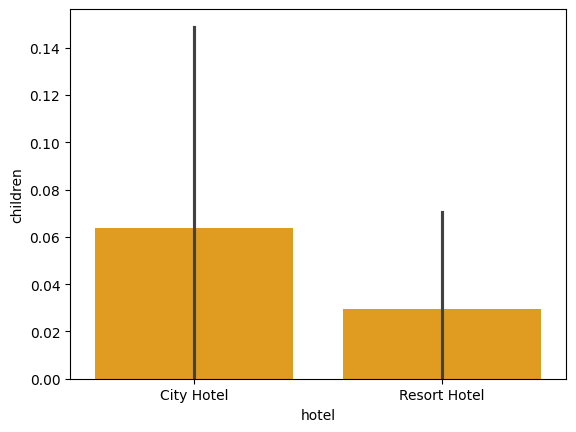

In [ ]:
sns.barplot(x='hotel',y='children',data=df,color='orange')

<Axes: xlabel='arrival_date_month', ylabel='arrival_date_day_of_month'>

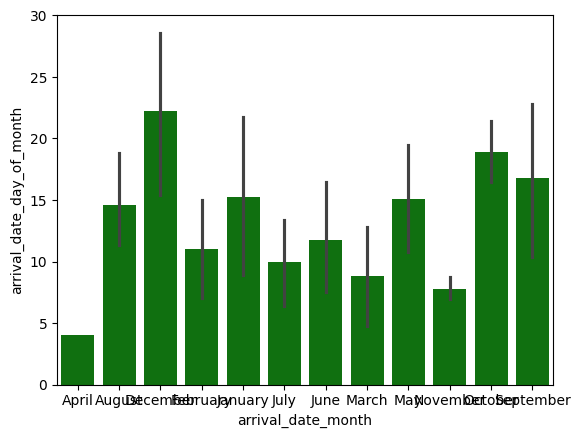

In [ ]:
sns.barplot(x='arrival_date_month',y='arrival_date_day_of_month',data=df,color='green')

<Axes: xlabel='arrival_date_month', ylabel='stays_in_weekend_nights'>

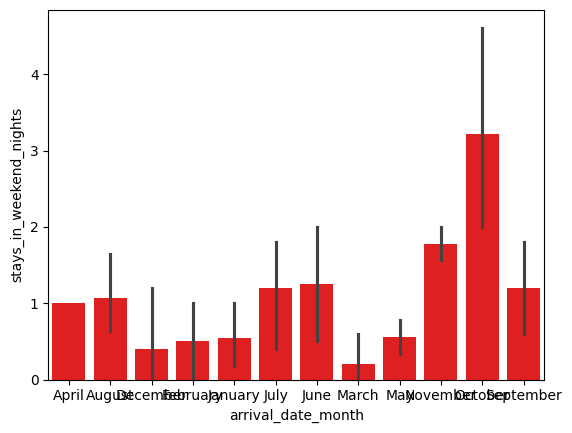

In [ ]:
sns.barplot(x='arrival_date_month',y='stays_in_weekend_nights',data=df,color='red')

<Axes: xlabel='hotel', ylabel='total_of_special_requests'>

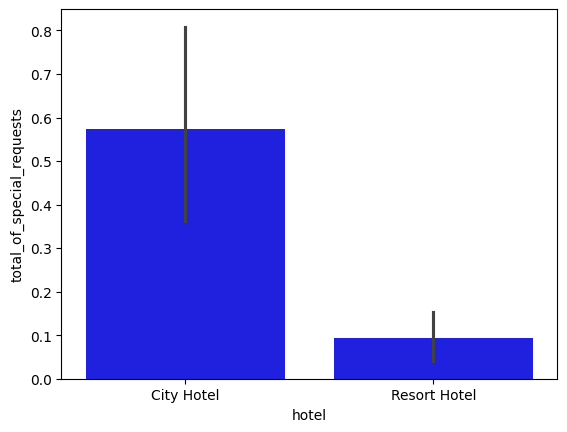

In [ ]:
sns.barplot(x='hotel',y='total_of_special_requests',data=df,color='blue')

<Axes: xlabel='customer_type', ylabel='company'>

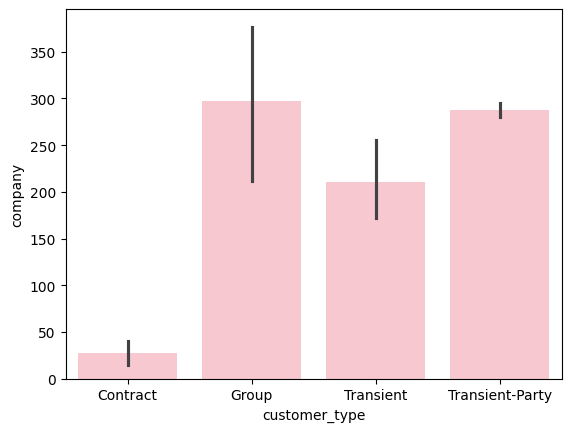

In [ ]:
sns.barplot(x='customer_type',y='company',data=df,color='pink')

<Axes: xlabel='assigned_room_type', ylabel='children'>

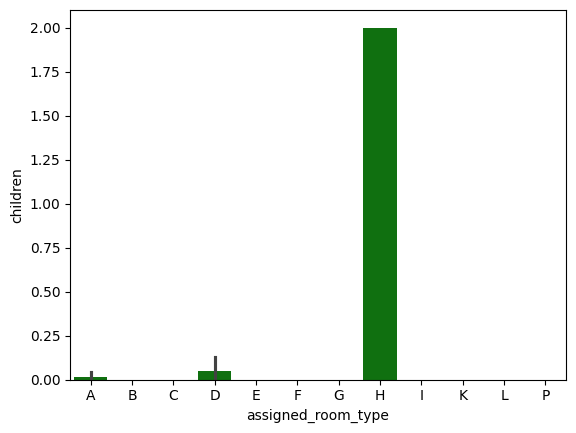

In [ ]:
sns.barplot(x='assigned_room_type',y='children',data=df,color='green')

<Axes: xlabel='assigned_room_type', ylabel='adults'>

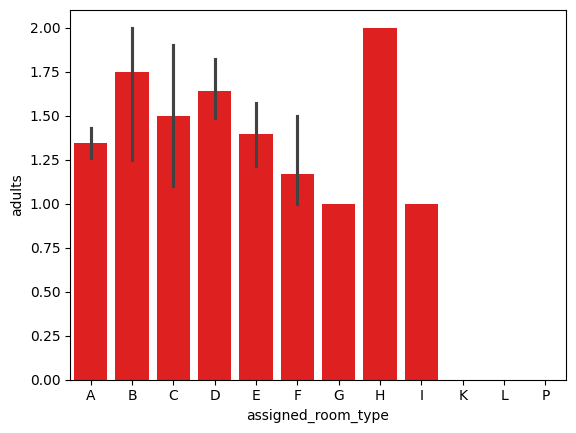

In [ ]:
sns.barplot(x='assigned_room_type',y='adults',data=df,color='red')

<Axes: xlabel='customer_type', ylabel='agent'>

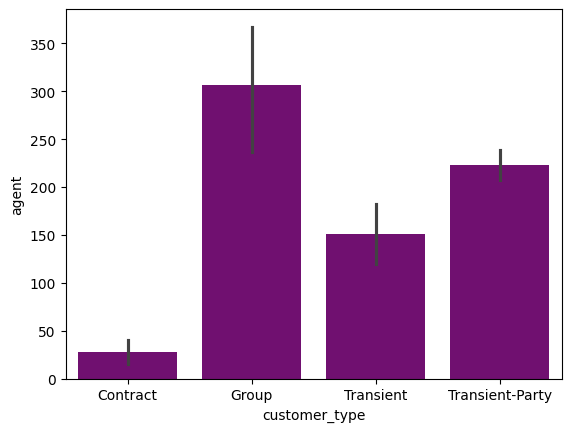

In [ ]:
sns.barplot(x='customer_type',y='agent',data=df,color='purple')

<Axes: xlabel='customer_type', ylabel='total_of_special_requests'>

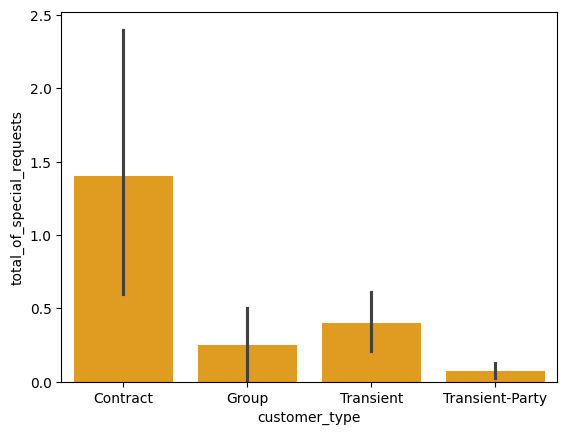

In [ ]:
sns.barplot(x='customer_type',y='total_of_special_requests',data=df,color='orange')

**MULTIVARIENT ANALYSIS**

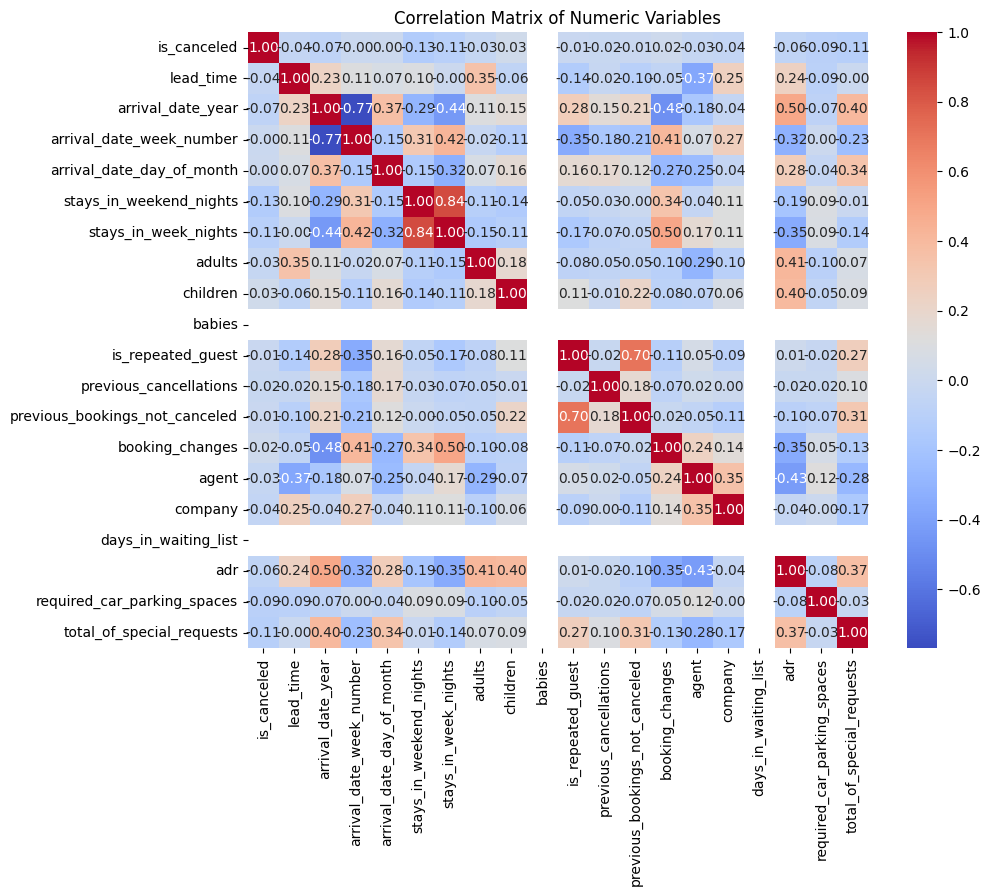

In [ ]:
numeric_cols=['is_canceled','lead_time','arrival_date_year','arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights','stays_in_week_nights','adults','children','babies','is_repeated_guest','previous_cancellations','previous_bookings_not_canceled','booking_changes','agent','company','days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests']

correlation_matrix = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Variables')
plt.show()

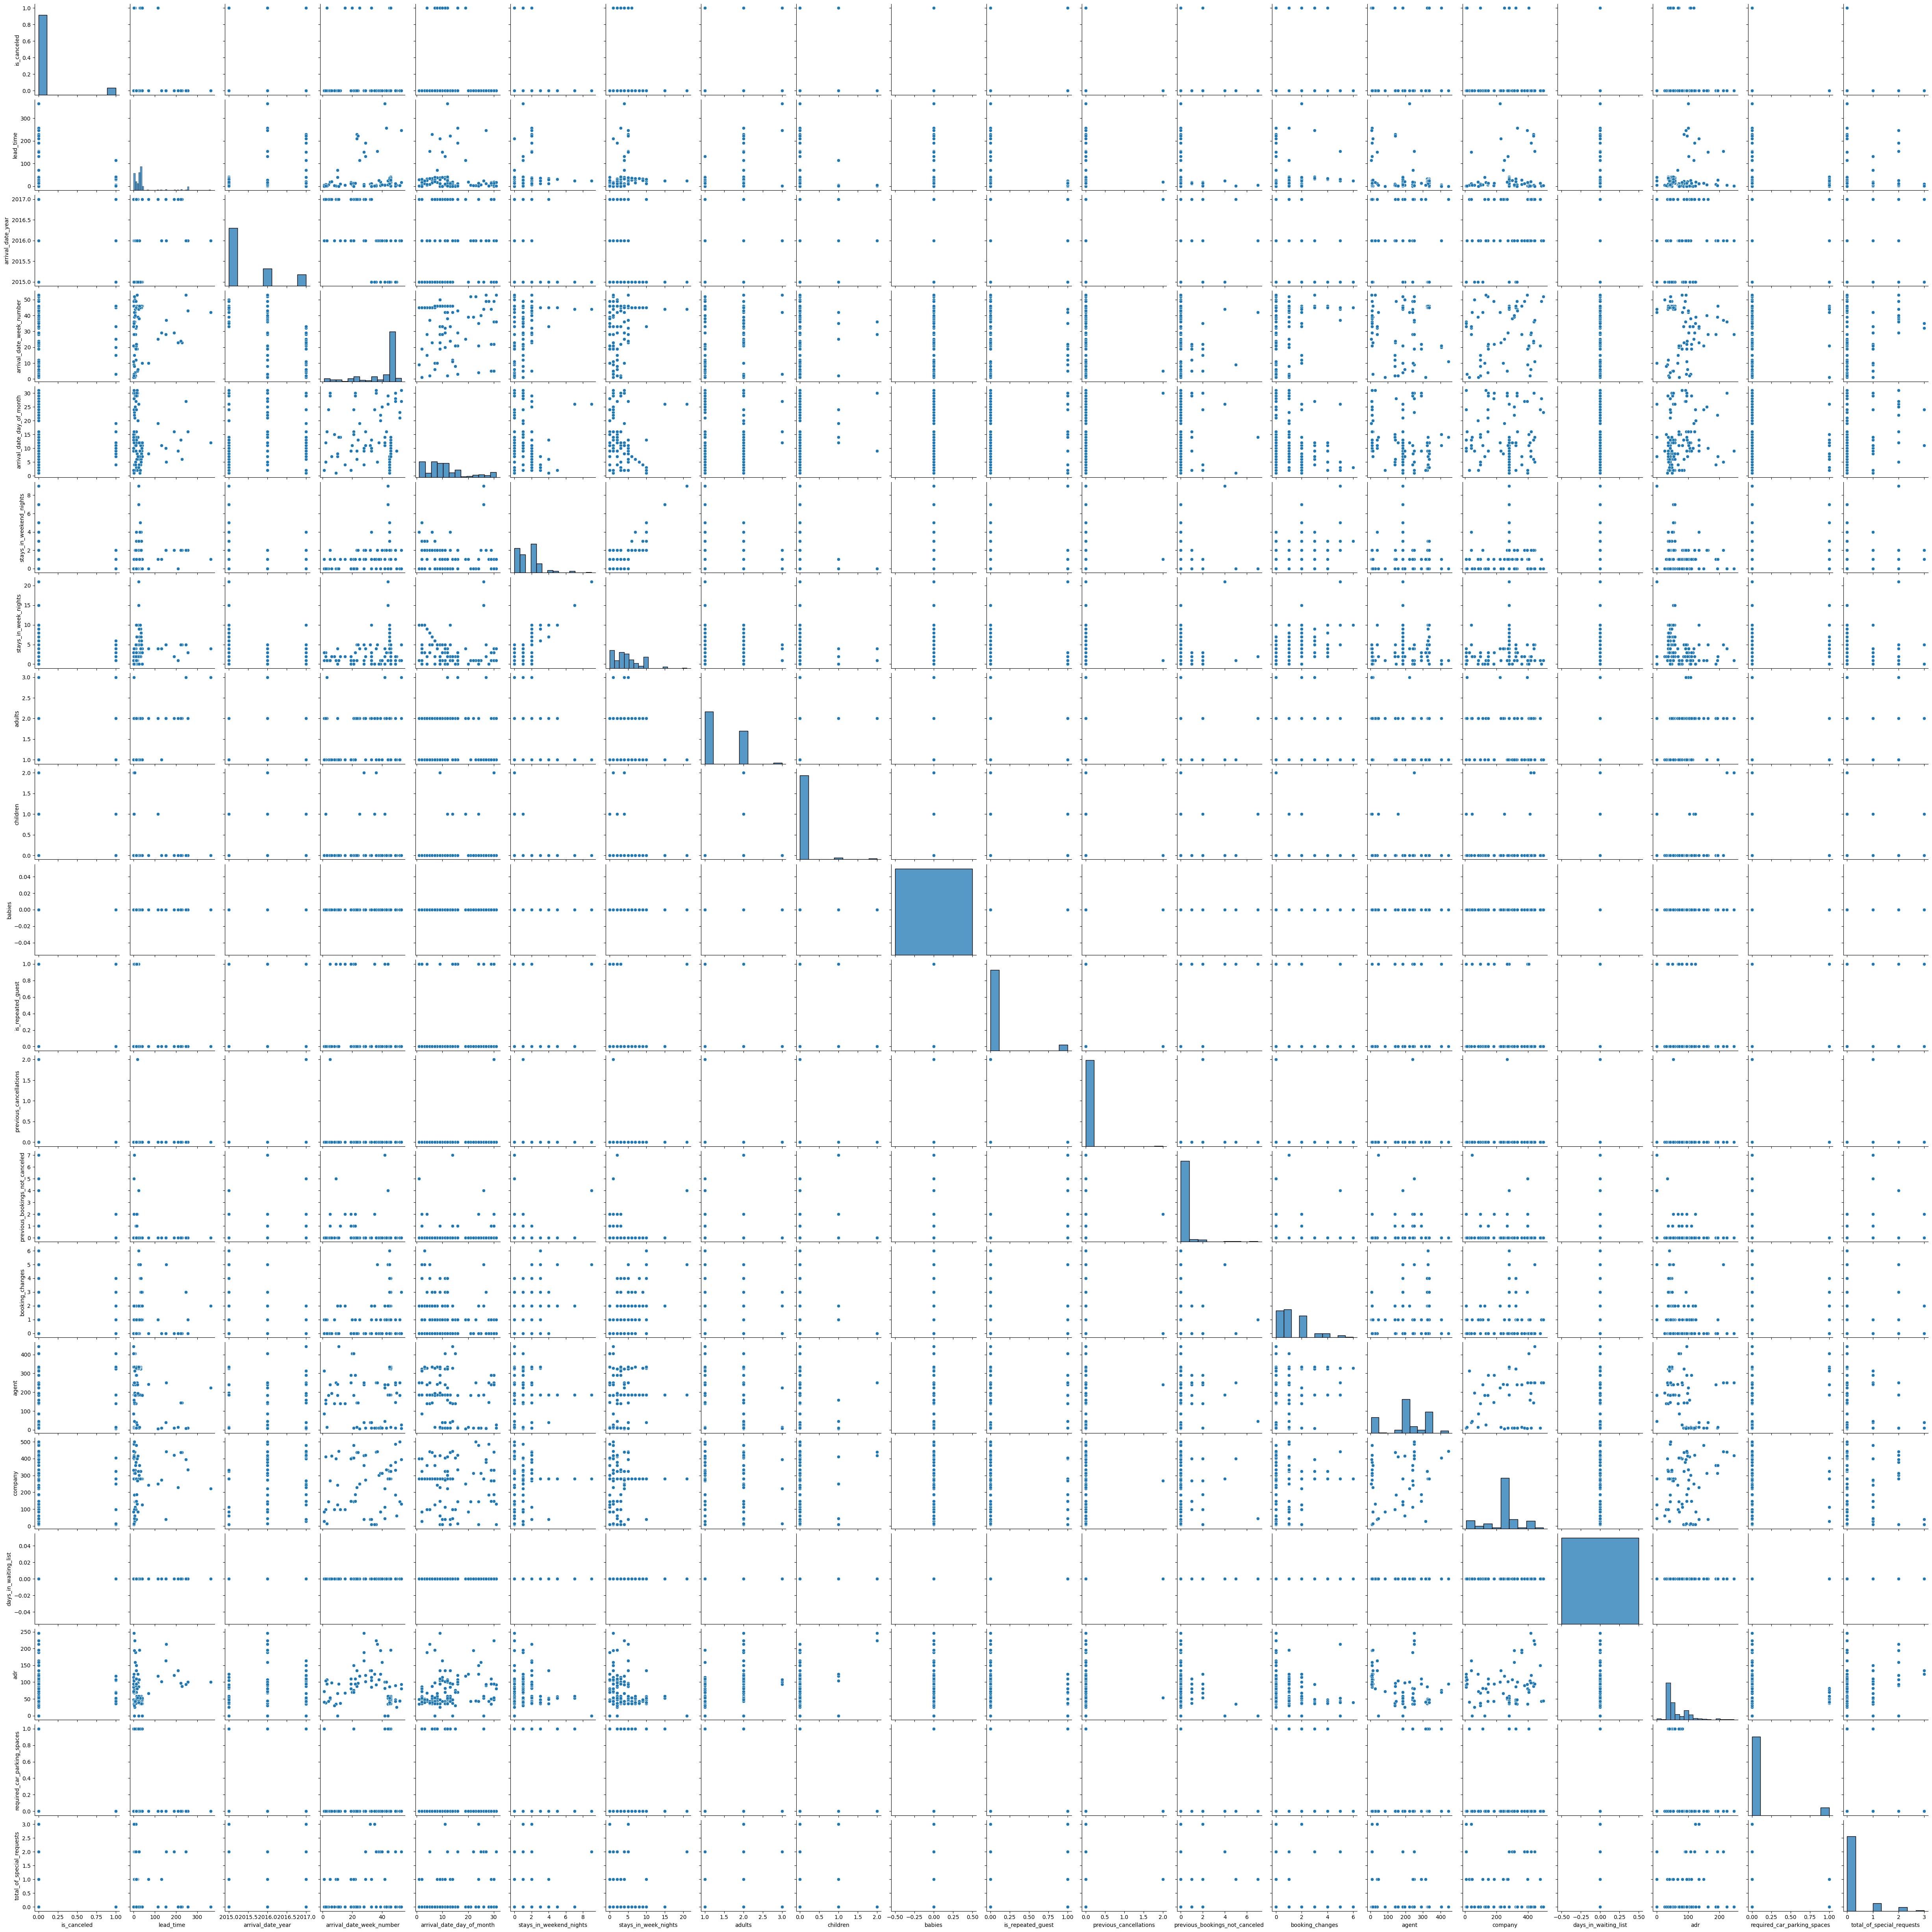

In [ ]:
numeric_cols=['is_canceled','lead_time','arrival_date_year','arrival_date_week_number','arrival_date_day_of_month','stays_in_weekend_nights','stays_in_week_nights','adults','children','babies','is_repeated_guest','previous_cancellations','previous_bookings_not_canceled','booking_changes','agent','company','days_in_waiting_list','adr','required_car_parking_spaces','total_of_special_requests']
sns.pairplot(df[numeric_cols])
plt.show()

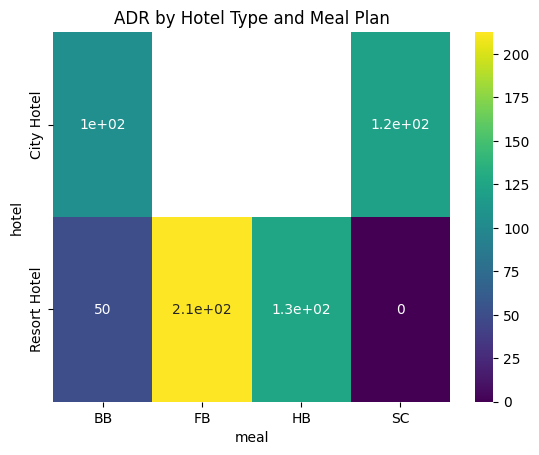

In [ ]:
pivot_table = df.pivot_table(values='adr', index='hotel', columns='meal', aggfunc='mean')
sns.heatmap(pivot_table, annot=True, cmap='viridis')
plt.title('ADR by Hotel Type and Meal Plan')
plt.show()
